In [ ]:
import os
import numpy as np
import cv2
import random

# Dossiers
base_path = "dataset"
train_x_path = os.path.join(base_path, "train/X")
train_o_path = os.path.join(base_path, "train/O")
test_x_path = os.path.join(base_path, "test/X")
test_o_path = os.path.join(base_path, "test/O")

# Création des dossiers
for path in [train_x_path, train_o_path, test_x_path, test_o_path]:
    os.makedirs(path, exist_ok=True)

# Fonction pour créer un X
def create_X():
    img = np.zeros((64, 64), dtype=np.uint8)
    thickness = random.randint(2, 5)
    cv2.line(img, (10, 10), (54, 54), 255, thickness)
    cv2.line(img, (54, 10), (10, 54), 255, thickness)
    return img

# Fonction pour créer un O
def create_O():
    img = np.zeros((64, 64), dtype=np.uint8)
    thickness = random.randint(2, 5)
    radius = random.randint(15, 25)
    cv2.circle(img, (32, 32), radius, 255, thickness)
    return img

# Génération images
def generate_images(path, label_func, count):
    for i in range(count):
        img = label_func()
        cv2.imwrite(os.path.join(path, f"{i}.png"), img)

# Train (80%)
generate_images(train_x_path, create_X, 200)
generate_images(train_o_path, create_O, 200)

# Test (20%)
generate_images(test_x_path, create_X, 50)
generate_images(test_o_path, create_O, 50)


In [ ]:
print(train_x_path)
print(train_o_path)

dataset/train/X
dataset/train/O


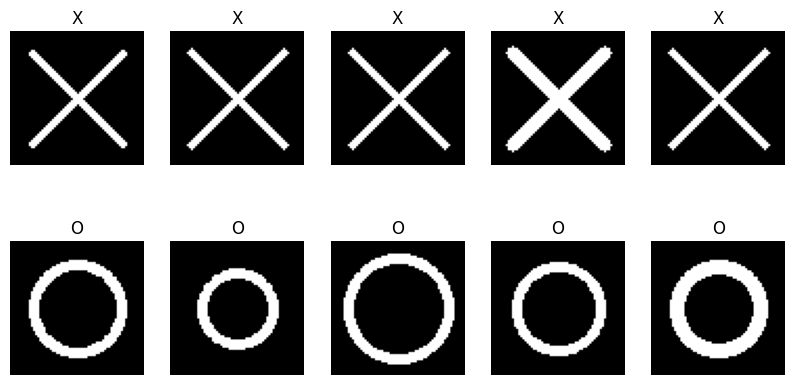

In [ ]:
import matplotlib.pyplot as plt
import os
import cv2

# Chemins
train_x_path = "dataset/train/X"
train_o_path = "dataset/train/O"

# Charger quelques images
x_images = os.listdir(train_x_path)[:5]
o_images = os.listdir(train_o_path)[:5]

plt.figure(figsize=(10,5))

# Afficher X
for i, img_name in enumerate(x_images):
    img = cv2.imread(os.path.join(train_x_path, img_name), cv2.IMREAD_GRAYSCALE)
    plt.subplot(2,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title("X")
    plt.axis('off')

# Afficher O
for i, img_name in enumerate(o_images):
    img = cv2.imread(os.path.join(train_o_path, img_name), cv2.IMREAD_GRAYSCALE)
    plt.subplot(2,5,i+6)
    plt.imshow(img, cmap='gray')
    plt.title("O")
    plt.axis('off')

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os

In [ ]:
base_repertoire = "dataset"
train_repertoire = os.path.join(base_repertoire,"train")
test_repertoire = os.path.join(base_repertoire,"test")

In [ ]:
#Normalisation des images (scalabilité a 1)
train_data_generat = ImageDataGenerator(rescale=1./255)
test_data_generat = ImageDataGenerator(rescale=1./255)

train_generateur = train_data_generat.flow_from_directory(
    train_repertoire,
    target_size=(64,64),
    batch_size=30,
    class_mode='binary',
    color_mode="grayscale"
)

test_generateur = test_data_generat.flow_from_directory(
    test_repertoire,
    target_size=(64,64),
    batch_size=30,
    class_mode='binary',
    color_mode="grayscale"
)

Found 2200 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [ ]:
#Notre model CNN 'Sequential"
model = Sequential()

#notre première couche 'layer' (Conv+ Pooling)
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

#notre 2éme couche
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

#La conversion de la matrice en vecteur
model.add(Flatten())

#LA couche finale "Dense"
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# La compilation de notre model.
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
#L'etape principale du model.
model.fit(train_generateur, epochs=3, validation_data=test_generateur)

Epoch 1/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 157ms/step - accuracy: 1.0000 - loss: 4.6729e-10 - val_accuracy: 1.0000 - val_loss: 1.2322e-09
Epoch 2/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 156ms/step - accuracy: 1.0000 - loss: 4.6559e-10 - val_accuracy: 1.0000 - val_loss: 1.2321e-09
Epoch 3/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 166ms/step - accuracy: 1.0000 - loss: 4.6555e-10 - val_accuracy: 1.0000 - val_loss: 1.2321e-09


In [ ]:
LOSS,ACCURACY = model.evaluate(test_generateur)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 1.2684e-09


In [ ]:
print("loss : ",LOSS)
print("accuracy : ",ACCURACY)

loss :  1.2683663008772328e-09
accuracy :  1.0


In [ ]:
from tensorflow.keras.preprocessing import image
import cv2
import random
import numpy as np

# Fonction pour créer un X
def create_X():
    img = np.zeros((64, 64), dtype=np.uint8)
    thickness = random.randint(2, 5)
    cv2.line(img, (10, 10), (54, 54), 255, thickness)
    cv2.line(img, (54, 10), (10, 54), 255, thickness)
    return img

# Fonction pour créer un O
def create_O():
    img = np.zeros((64, 64), dtype=np.uint8)
    thickness = random.randint(2, 5)
    radius = random.randint(15, 25)
    cv2.circle(img, (32, 32), radius, 255, thickness)
    return img
image_test_chemain = "image_test.png"


#On va generer une image aléatoire.
if not os.path.exists(image_test_chemain):
  if random.choice([True,False]):
    img = create_X()
  else:
    img = create_O()
  cv2.imwrite(image_test_chemain, img)

imageT = image.load_img(image_test_chemain, target_size=(64,64), color_mode="grayscale")
image_array = image.img_to_array(imageT)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model.predict(image_array)
print(prediction)

if prediction > 0.5:
  print("X")
else:
  print("O")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[1.]]
X


In [ ]:
#je veux